In [45]:
import os
import sys
import random
import warnings
warnings.filterwarnings("ignore")

# Add project root to Python path
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import tifffile

from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from models.rgb_model import create_rgb_model
from models.ms_model import MultiSpectralCNN

In [46]:
RGB_DIR = "../EuroSAT_Dataset/EuroSAT"
MS_DIR = "../EuroSAT_Dataset/EuroSATallBands"

VAL_CSV = "../EuroSAT_Dataset/validation.csv"

RGB_MODEL_PATH = "../checkpoints/best_rgb_model.pth"
MS_MODEL_PATH = "../checkpoints/best_ms.pth"

PREDICTION_DIR = "../outputs/predictions"
FIGURE_DIR = "../outputs/figures"

os.makedirs(PREDICTION_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

In [47]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [48]:
CLASS_NAMES = [
    "AnnualCrop",
    "Forest",
    "HerbaceousVegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "PermanentCrop",
    "Residential",
    "River",
    "SeaLake"
]

In [49]:
rgb_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [50]:
import json

with open("../ms_band_stats.json", "r") as f:
    band_stats = json.load(f)

MEAN = np.array(band_stats["mean"], dtype=np.float32)
STD = np.array(band_stats["std"], dtype=np.float32)

print("Band statistics loaded successfully.")

Band statistics loaded successfully.


In [51]:
def compute_indices(img):
    """
    img shape: (13, H, W)
    Returns: NDVI, NDWI, NBR -> (3, H, W)
    """

    eps = 1e-6

    # Sentinel-2 bands
    green = img[2]     # B3
    red = img[3]       # B4
    nir = img[7]       # B8
    swir2 = img[11]    # B12

    ndvi = (nir - red) / (nir + red + eps)

    ndwi = (green - nir) / (green + nir + eps)

    nbr = (nir - swir2) / (nir + swir2 + eps)

    return np.stack([ndvi, ndwi, nbr], axis=0).clip(-1, 1)

In [52]:
class RGBDataset(Dataset):

    def __init__(self, csv_file):
        self.df = pd.read_csv(csv_file)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_path = os.path.join(
            RGB_DIR,
            "val",
            row["classname"],
            os.path.basename(row["filename"])
        )

        image = Image.open(image_path).convert("RGB")
        image = rgb_transform(image)

        label = int(row["label"])

        return image, label, image_path, row["classname"]

In [53]:
class MSDataset(Dataset):

    def __init__(self, csv_file):
        self.df = pd.read_csv(csv_file)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        tif_name = os.path.basename(
            row["filename"]
        ).replace(".jpg", ".tif")

        image_path = os.path.join(
            MS_DIR,
            "val",
            row["classname"],
            tif_name
        )

        image = tifffile.imread(image_path).astype(np.float32)

        # Convert HWC → CHW if needed
        if image.shape[-1] == 13:
            image = image.transpose(2, 0, 1)

        # Compute spectral indices from normalized bands
        indices = compute_indices(image)

        # Normalize 13 bands
        image = (image - MEAN[:, None, None]) / (STD[:, None, None] + 1e-6)

        # 13 + 3 = 16 channels
        image = np.concatenate([image, indices], axis=0)

        image = torch.tensor(image, dtype=torch.float32)

        label = int(row["label"])

        return image, label, image_path, row["classname"]

In [54]:
rgb_dataset = RGBDataset(VAL_CSV)
ms_dataset = MSDataset(VAL_CSV)

rgb_loader = DataLoader(
    rgb_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

ms_loader = DataLoader(
    ms_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

print("RGB Validation Images :", len(rgb_dataset))
print("MS Validation Images  :", len(ms_dataset))

RGB Validation Images : 4050
MS Validation Images  : 4050


In [55]:
rgb_model = create_rgb_model()

checkpoint = torch.load(
    RGB_MODEL_PATH,
    map_location=device
)

rgb_model.load_state_dict(checkpoint)

rgb_model = rgb_model.to(device)
rgb_model.eval()

print("RGB model loaded successfully.")

RGB model loaded successfully.


In [56]:
ms_model = MultiSpectralCNN(
    in_ch=16,
    nc=10
)

checkpoint = torch.load(
    MS_MODEL_PATH,
    map_location=device
)

ms_model.load_state_dict(checkpoint)

ms_model = ms_model.to(device)
ms_model.eval()

print("MS model loaded successfully.")

MS model loaded successfully.


In [57]:
rgb_results = []

with torch.no_grad():

    for images, labels, paths, classnames in rgb_loader:

        images = images.to(device)

        outputs = rgb_model(images)

        predictions = outputs.argmax(dim=1).cpu().numpy()

        for i in range(len(labels)):

            rgb_results.append({

                "filename": paths[i],

                "classname": classnames[i],

                "true_label": int(labels[i]),

                "predicted_label": int(predictions[i])

            })

print("RGB predictions completed.")

RGB predictions completed.


In [58]:
rgb_predictions = pd.DataFrame(rgb_results)

rgb_predictions.to_csv(
    os.path.join(
        PREDICTION_DIR,
        "rgb_val_predictions.csv"
    ),
    index=False
)

rgb_predictions.tail()


,filename,classname,true_label,predicted_label
4045,../EuroSAT_Dataset/EuroSAT\val\SeaLake\SeaLake...,SeaLake,9,9
4046,../EuroSAT_Dataset/EuroSAT\val\SeaLake\SeaLake...,SeaLake,9,9
4047,../EuroSAT_Dataset/EuroSAT\val\SeaLake\SeaLake...,SeaLake,9,9
4048,../EuroSAT_Dataset/EuroSAT\val\SeaLake\SeaLake...,SeaLake,9,9
4049,../EuroSAT_Dataset/EuroSAT\val\SeaLake\SeaLake...,SeaLake,9,9


In [59]:
ms_results = []

with torch.no_grad():

    for images, labels, paths, classnames in ms_loader:

        images = images.to(device)

        outputs = ms_model(images)

        predictions = outputs.argmax(dim=1).cpu().numpy()

        for i in range(len(labels)):

            ms_results.append({

                "filename": paths[i],

                "classname": classnames[i],

                "true_label": int(labels[i]),

                "predicted_label": int(predictions[i])

            })

print("MS predictions completed.")

MS predictions completed.


In [60]:
ms_predictions = pd.DataFrame(ms_results)

ms_predictions.to_csv(
    os.path.join(
        PREDICTION_DIR,
        "ms_val_predictions.csv"
    ),
    index=False
)

ms_predictions.head()

,filename,classname,true_label,predicted_label
0,../EuroSAT_Dataset/EuroSATallBands\val\AnnualC...,AnnualCrop,0,0
1,../EuroSAT_Dataset/EuroSATallBands\val\AnnualC...,AnnualCrop,0,0
2,../EuroSAT_Dataset/EuroSATallBands\val\AnnualC...,AnnualCrop,0,0
3,../EuroSAT_Dataset/EuroSATallBands\val\AnnualC...,AnnualCrop,0,0
4,../EuroSAT_Dataset/EuroSATallBands\val\AnnualC...,AnnualCrop,0,0


In [61]:
rgb_correct = rgb_predictions[
    rgb_predictions["true_label"] ==
    rgb_predictions["predicted_label"]
].reset_index(drop=True)

rgb_incorrect = rgb_predictions[
    rgb_predictions["true_label"] !=
    rgb_predictions["predicted_label"]
].reset_index(drop=True)

print(f"Correct RGB Predictions   : {len(rgb_correct)}")
print(f"Incorrect RGB Predictions : {len(rgb_incorrect)}")


ms_correct = ms_predictions[
    ms_predictions["true_label"] ==
    ms_predictions["predicted_label"]
].reset_index(drop=True)

ms_incorrect = ms_predictions[
    ms_predictions["true_label"] !=
    ms_predictions["predicted_label"]
].reset_index(drop=True)

print(f"\nCorrect MS Predictions   : {len(ms_correct)}")
print(f"Incorrect MS Predictions : {len(ms_incorrect)}")

Correct RGB Predictions   : 3906
Incorrect RGB Predictions : 144

Correct MS Predictions   : 4007
Incorrect MS Predictions : 43


Grad-CAM (Visual Explainability)

In [62]:
import cv2
import torch.nn.functional as F

class GradCAM:

    def __init__(self, model, target_layer):

        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.forward_hook = target_layer.register_forward_hook(
            self.save_activation
        )

        self.backward_hook = target_layer.register_full_backward_hook(
            self.save_gradient
        )

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, image, class_idx=None):

        self.model.zero_grad()

        output = self.model(image)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        score = output[:, class_idx]
        score.backward()

        gradients = self.gradients.mean(dim=(2,3), keepdim=True)

        cam = (gradients * self.activations).sum(dim=1)

        cam = F.relu(cam)

        cam = cam.squeeze().detach().cpu().numpy()

        cam -= cam.min()

        cam /= (cam.max() + 1e-8)

        return cam

In [63]:
target_layer = rgb_model.features[-1]

grad_cam = GradCAM(
    rgb_model,
    target_layer
)

print("GradCAM initialized successfully.")

GradCAM initialized successfully.


In [64]:
def preprocess_image(image_path):

    image = Image.open(image_path).convert("RGB")

    original = np.array(image)

    tensor = rgb_transform(image).unsqueeze(0).to(device)

    return original, tensor

In [65]:
def overlay_heatmap(original, cam):

    cam = cv2.resize(
        cam,
        (original.shape[1], original.shape[0])
    )

    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam),
        cv2.COLORMAP_JET
    )

    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )

    overlay = np.clip(
        original * 0.6 + heatmap * 0.4,
        0,
        255
    ).astype(np.uint8)

    return heatmap, overlay

In [66]:
def show_gradcam(image_path, title=""):

    original, tensor = preprocess_image(image_path)

    cam = grad_cam.generate(tensor)

    heatmap, overlay = overlay_heatmap(
        original,
        cam
    )

    fig, ax = plt.subplots(
        1,
        3,
        figsize=(12,4)
    )

    ax[0].imshow(original)
    ax[0].set_title("Original")
    ax[0].axis("off")

    ax[1].imshow(heatmap)
    ax[1].set_title("Heatmap")
    ax[1].axis("off")

    ax[2].imshow(overlay)
    ax[2].set_title("Overlay")
    ax[2].axis("off")

    plt.suptitle(title)

    plt.tight_layout()

    plt.show()

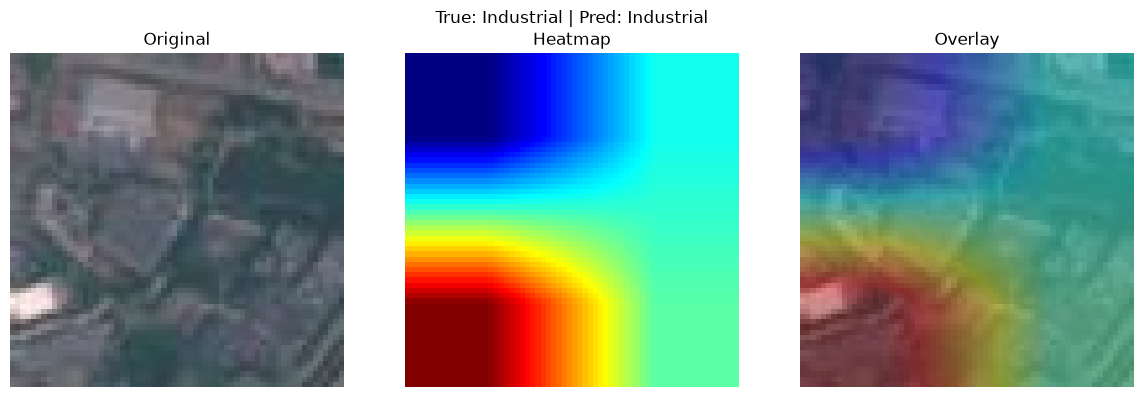

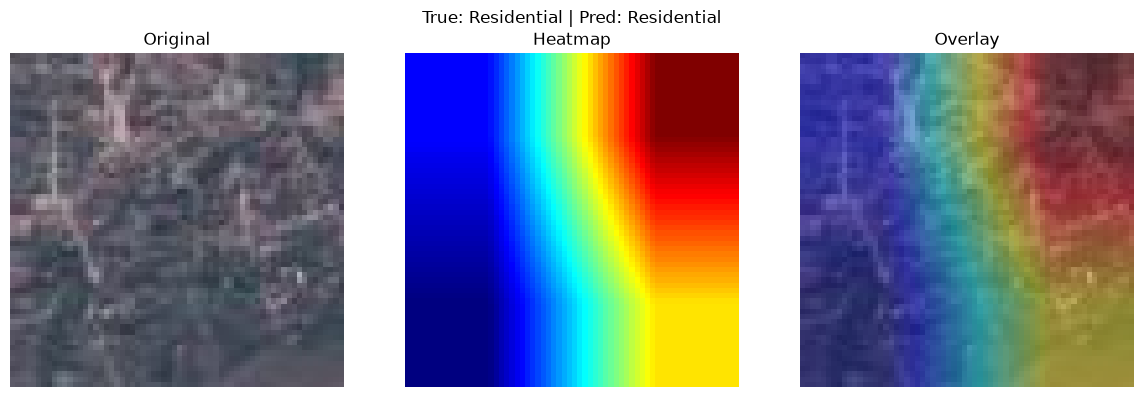

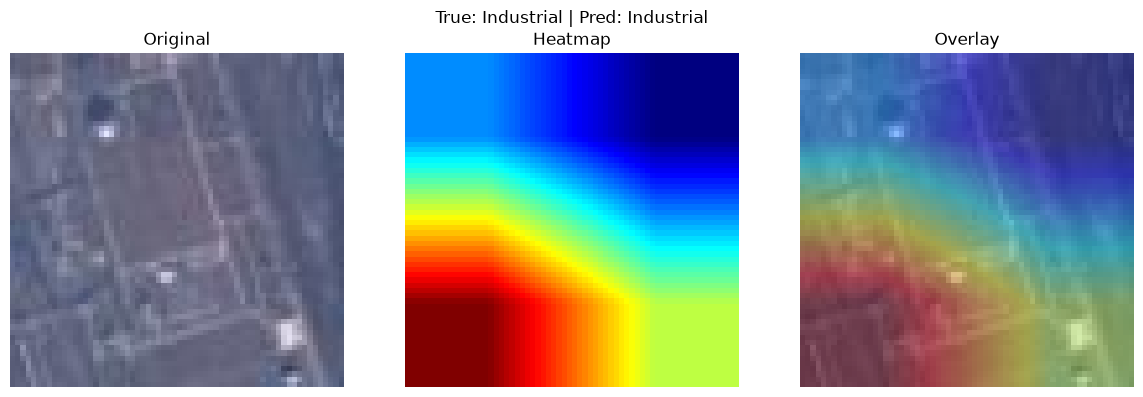

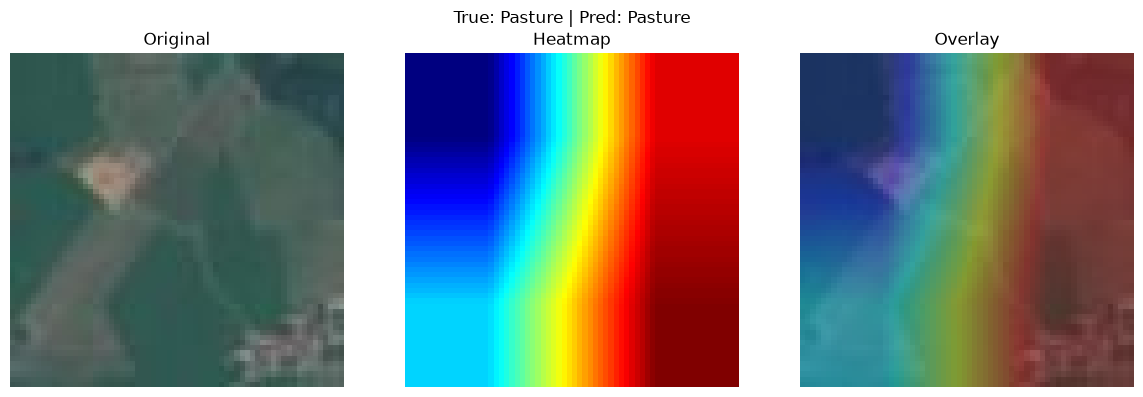

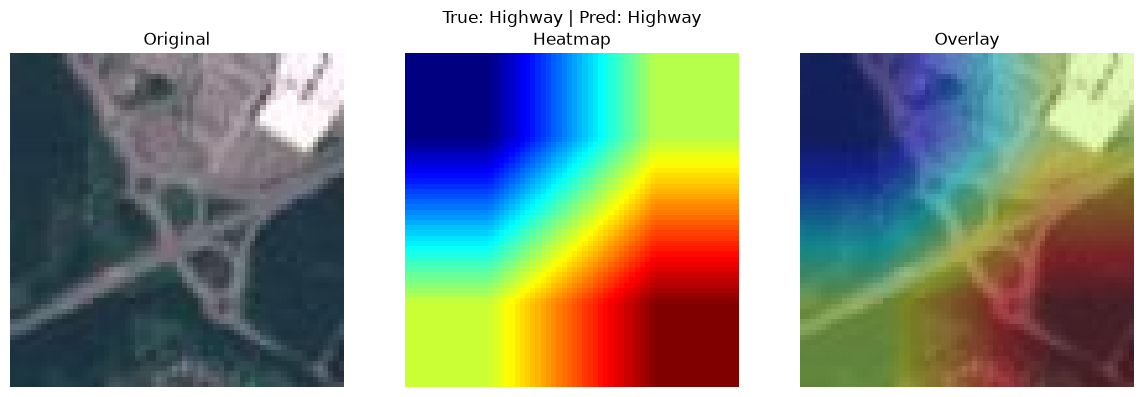

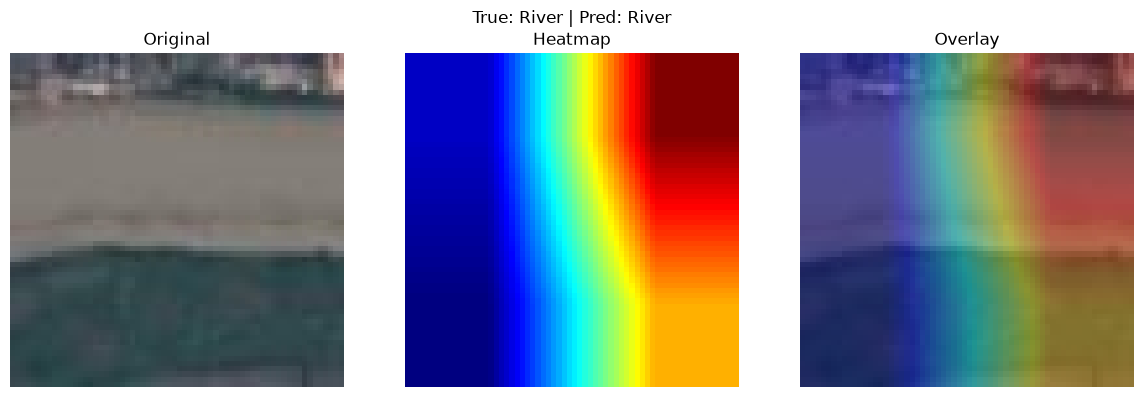

In [67]:
sample_correct = rgb_correct.sample(
    6,
    random_state=42
)

for _, row in sample_correct.iterrows():

    title = (
        f"True: {CLASS_NAMES[row.true_label]} | "
        f"Pred: {CLASS_NAMES[row.predicted_label]}"
    )

    show_gradcam(
        row.filename,
        title
    )

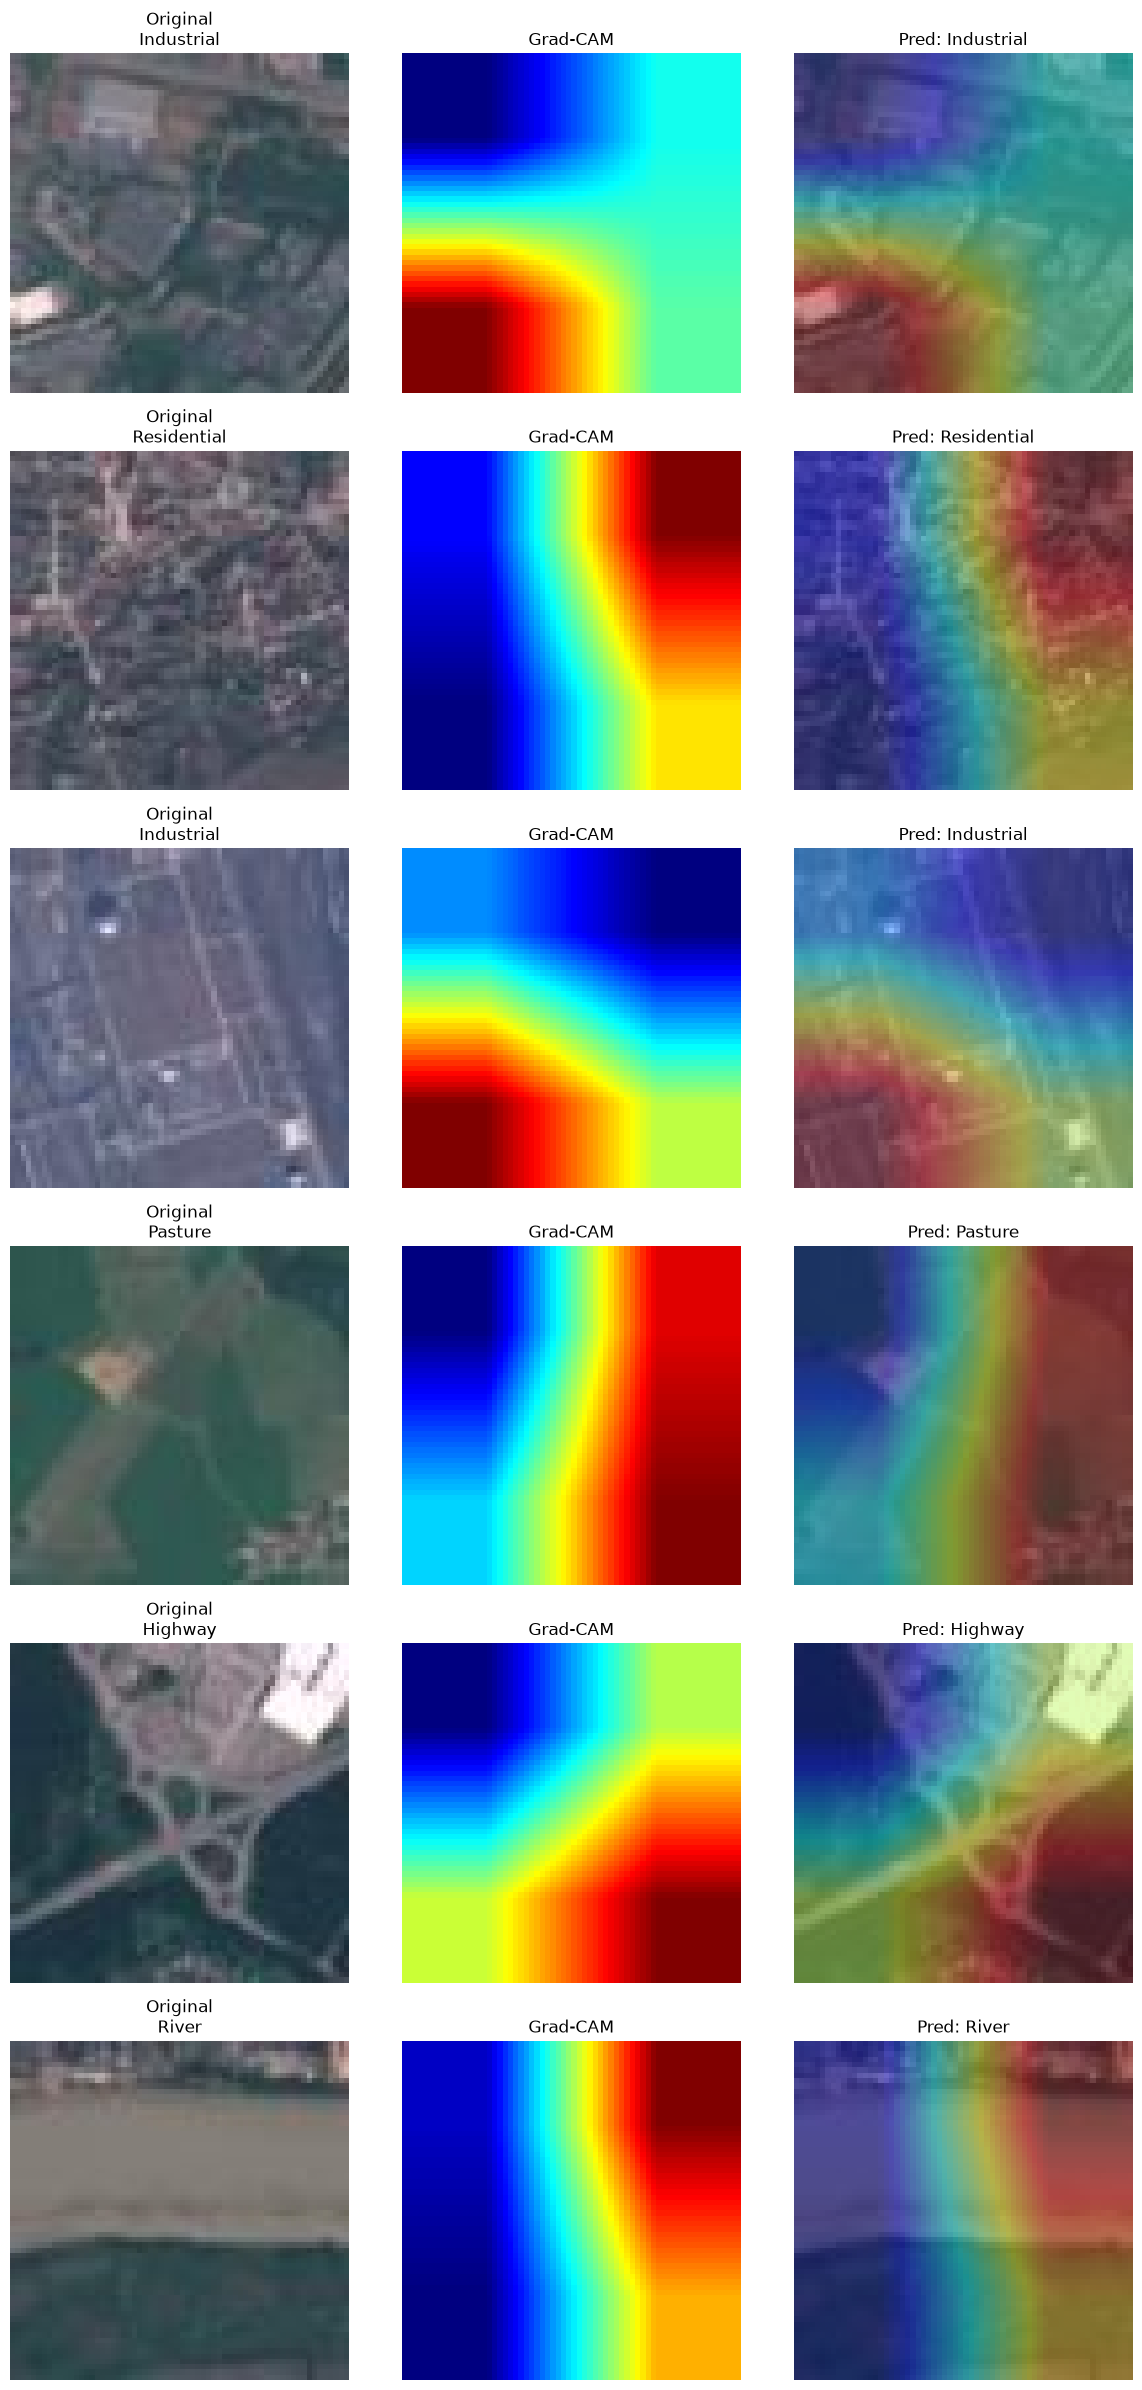

Figure saved at:
../outputs/figures\gradcam_correct.png


In [68]:
# Number of correct samples to visualize
num_samples = min(6, len(rgb_correct))

sample_correct = rgb_correct.sample(
    n=num_samples,
    random_state=42
).reset_index(drop=True)

fig, axes = plt.subplots(
    num_samples,
    3,
    figsize=(12, 4 * num_samples)
)

if num_samples == 1:
    axes = np.expand_dims(axes, axis=0)

for i, row in sample_correct.iterrows():

    original, tensor = preprocess_image(row["filename"])

    cam = grad_cam.generate(tensor)

    heatmap, overlay = overlay_heatmap(original, cam)

    # Original
    axes[i,0].imshow(original)
    axes[i,0].set_title(
        f"Original\n{CLASS_NAMES[row['true_label']]}"
    )
    axes[i,0].axis("off")

    # Heatmap
    axes[i,1].imshow(heatmap)
    axes[i,1].set_title("Grad-CAM")
    axes[i,1].axis("off")

    # Overlay
    axes[i,2].imshow(overlay)
    axes[i,2].set_title(
        f"Pred: {CLASS_NAMES[row['predicted_label']]}"
    )
    axes[i,2].axis("off")

plt.tight_layout()

save_path = os.path.join(
    FIGURE_DIR,
    "gradcam_correct.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved at:\n{save_path}")

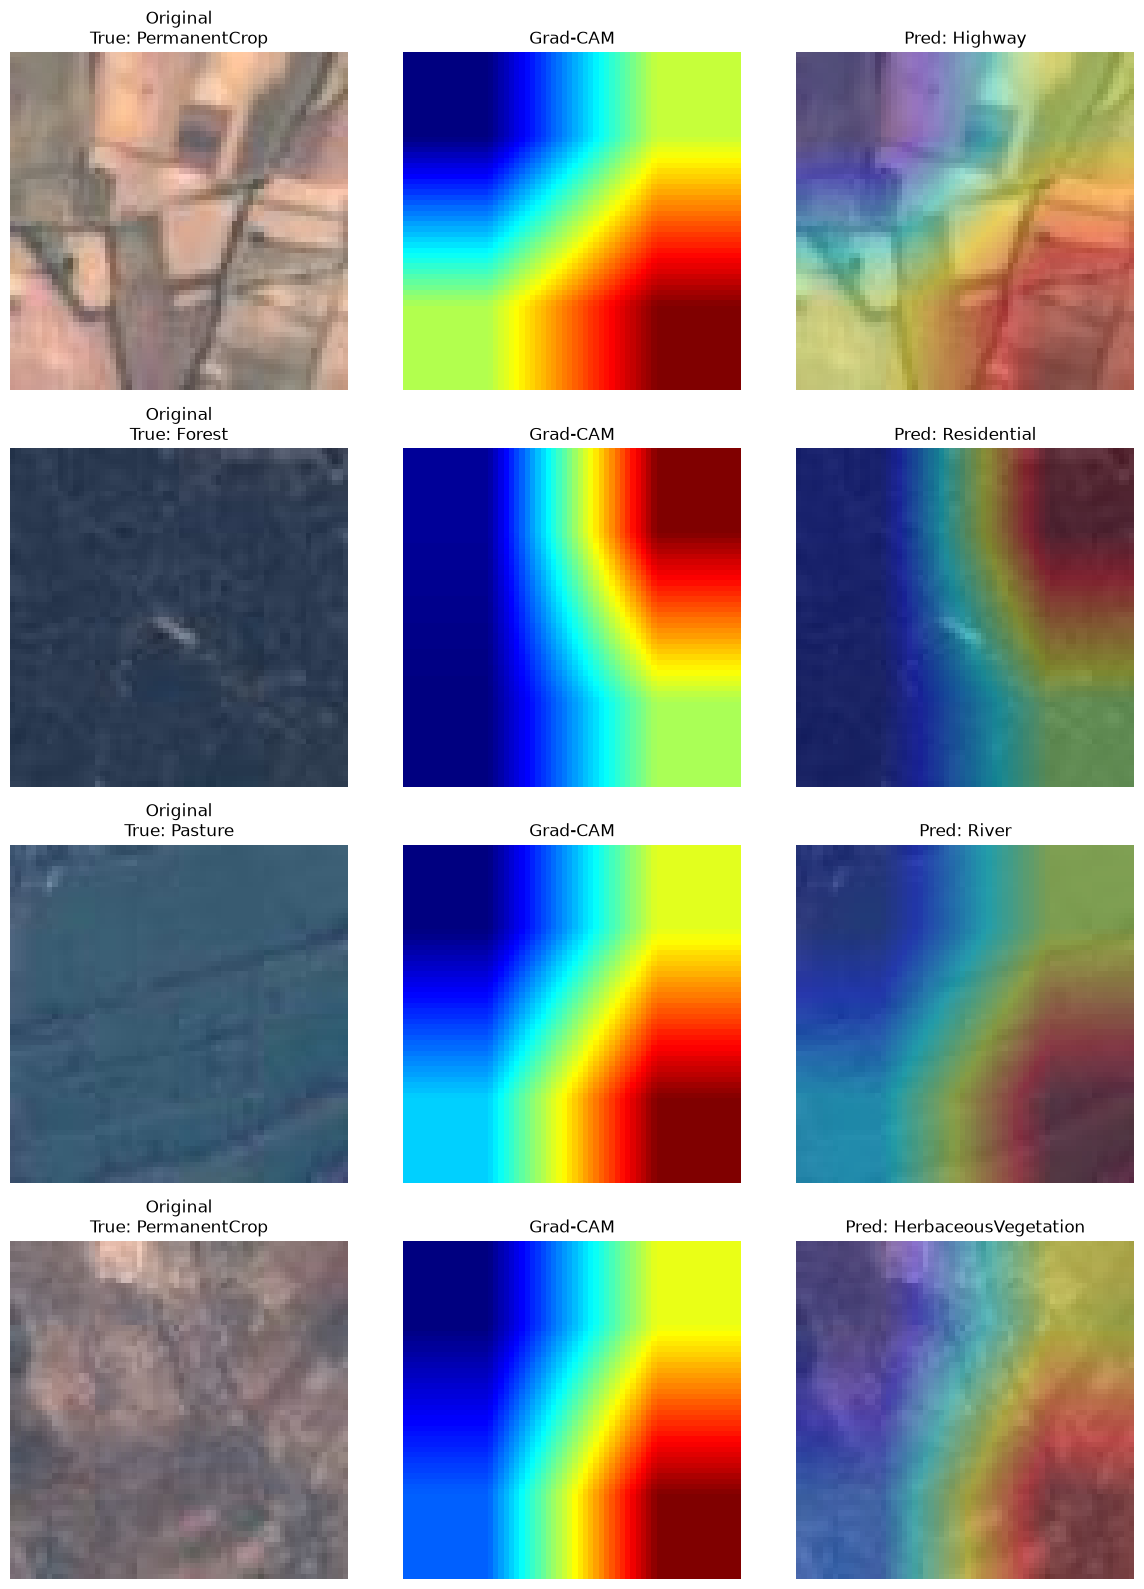

Figure saved at:
../outputs/figures\gradcam_incorrect.png


In [69]:
# Number of incorrect samples to visualize
num_samples = min(4, len(rgb_incorrect))

sample_incorrect = rgb_incorrect.sample(
    n=num_samples,
    random_state=42
).reset_index(drop=True)

fig, axes = plt.subplots(
    num_samples,
    3,
    figsize=(12, 4 * num_samples)
)

if num_samples == 1:
    axes = np.expand_dims(axes, axis=0)

for i, row in sample_incorrect.iterrows():

    original, tensor = preprocess_image(row["filename"])

    cam = grad_cam.generate(tensor)

    heatmap, overlay = overlay_heatmap(original, cam)

    # Original Image
    axes[i,0].imshow(original)
    axes[i,0].set_title(
        f"Original\nTrue: {CLASS_NAMES[row['true_label']]}"
    )
    axes[i,0].axis("off")

    # Heatmap
    axes[i,1].imshow(heatmap)
    axes[i,1].set_title("Grad-CAM")
    axes[i,1].axis("off")

    # Overlay
    axes[i,2].imshow(overlay)
    axes[i,2].set_title(
        f"Pred: {CLASS_NAMES[row['predicted_label']]}"
    )
    axes[i,2].axis("off")

plt.tight_layout()

save_path = os.path.join(
    FIGURE_DIR,
    "gradcam_incorrect.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved at:\n{save_path}")

## Interpretation of Correct Grad-CAM

The Grad-CAM visualizations for correctly classified samples indicate that the RGB model focuses on meaningful and discriminative regions within the images.

- **Forest:** The model primarily attends to dense canopy textures and vegetation patterns.
- **Residential:** Strong attention is observed on buildings, road layouts, and urban structures.
- **River:** The highlighted regions correspond closely to water bodies and river boundaries.
- **SeaLake:** The model focuses on large homogeneous water regions.
- **AnnualCrop:** Agricultural field patterns and crop textures receive the highest attention.

These observations suggest that the model has learned class-specific visual characteristics and bases its predictions on relevant image regions.

## Interpretation of Incorrect Grad-CAM

The Grad-CAM visualizations for incorrectly classified samples reveal the limitations of the RGB model.

Common observations include:

- Attention is sometimes concentrated on background regions instead of the primary land-cover object.
- Visually similar classes such as **AnnualCrop** and **PermanentCrop** exhibit overlapping textures, causing confusion.
- **River** and **SeaLake** may share similar blue color distributions, leading to incorrect predictions.
- Urban categories such as **Industrial** and **Residential** contain similar man-made structures, making visual separation difficult.

These failure cases demonstrate that RGB imagery alone may not always provide sufficient spectral information for accurate discrimination.

Part B – Band Importance (Spectral Explainability)

In [70]:
BAND_NAMES = [
    "B1 (Coastal)",
    "B2 (Blue)",
    "B3 (Green)",
    "B4 (Red)",
    "B5 (Red Edge 1)",
    "B6 (Red Edge 2)",
    "B7 (Red Edge 3)",
    "B8 (NIR)",
    "B8A (Narrow NIR)",
    "B9 (Water Vapour)",
    "B10 (Cirrus)",
    "B11 (SWIR1)",
    "B12 (SWIR2)"
]

In [71]:
band_importance = np.zeros(13)

num_samples = 0

ms_model.eval()

for images, labels, _, _ in ms_loader:

    images = images.to(device)
    labels = labels.to(device)

    images.requires_grad_(True)

    outputs = ms_model(images)

    loss = outputs.gather(
        1,
        labels.view(-1,1)
    ).sum()

    ms_model.zero_grad()

    loss.backward()

    grads = images.grad.abs()

    band_importance += grads[:, :13].mean(
        dim=(0,2,3)
    ).cpu().numpy()

    num_samples += images.size(0)

    if num_samples >= 200:
        break

band_importance /= (num_samples / images.size(0))

print("Band importance computed.")

Band importance computed.


In [72]:
importance_df = pd.DataFrame({

    "Band": BAND_NAMES,

    "Importance": band_importance

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

importance_df

,Band,Importance
0,B2 (Blue),0.001106
1,B3 (Green),0.000972
2,B1 (Coastal),0.000857
3,B4 (Red),0.000750
4,B7 (Red Edge 3),0.000657
5,B11 (SWIR1),0.000623
6,B9 (Water Vapour),0.000568
7,B5 (Red Edge 1),0.000559
8,B8A (Narrow NIR),0.000533
9,B8 (NIR),0.000481


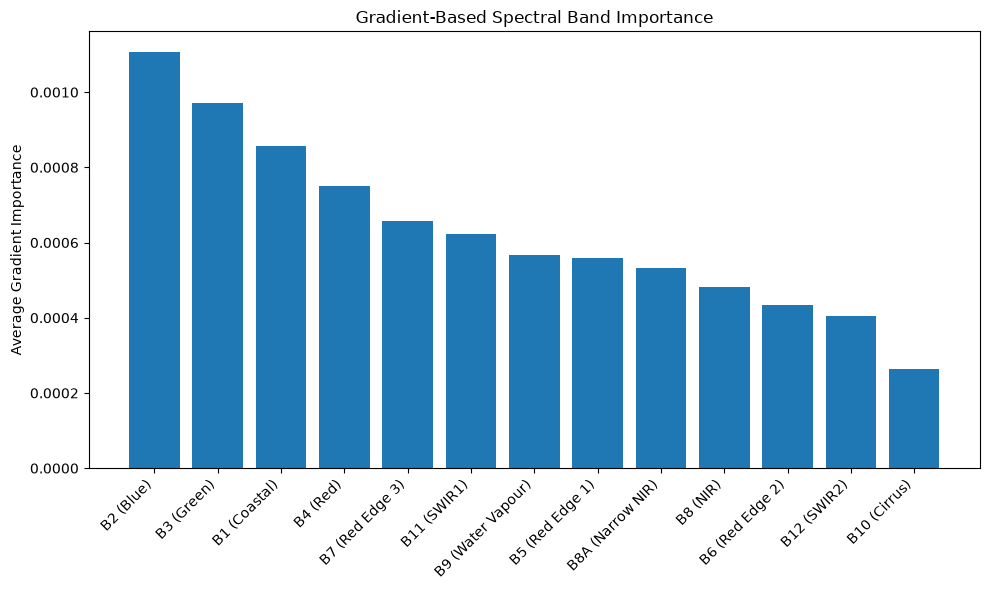

Saved to:
../outputs/figures\band_importance.png


In [73]:
plt.figure(figsize=(10,6))

plt.bar(
    importance_df["Band"],
    importance_df["Importance"]
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylabel("Average Gradient Importance")

plt.title("Gradient-Based Spectral Band Importance")

plt.tight_layout()

save_path = os.path.join(
    FIGURE_DIR,
    "band_importance.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved to:\n{save_path}")

## Interpretation of Spectral Band Importance

The gradient-based analysis highlights which Sentinel-2 bands contribute most to the multispectral model's predictions.

Typical observations include:

- **B8 (Near Infrared)** is expected to be highly important because vegetation strongly reflects NIR radiation, making it useful for distinguishing Forest, Pasture, and AnnualCrop.
- **B11** and **B12 (Shortwave Infrared)** help separate vegetation, built-up regions, and bare surfaces due to differences in moisture content and material properties.
- **Red Edge bands (B5–B7)** provide valuable information about vegetation health and crop discrimination.
- Visible bands (Blue, Green, and Red) mainly contribute to color and texture information.

### Role of Spectral Indices

The multispectral model also uses three derived indices:

- **NDVI** emphasizes vegetation density and health.
- **NDWI** highlights water bodies and moisture content.
- **NBR** assists in distinguishing vegetation and burned or dry areas through the relationship between NIR and SWIR bands.

These indices complement the original spectral bands by providing high-level features that improve class separability.

Part C — Confusion Matrix & Error Analysis

In [74]:
CLASS_NAMES = [
    "AnnualCrop",
    "Forest",
    "HerbaceousVegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "PermanentCrop",
    "Residential",
    "River",
    "SeaLake"
]

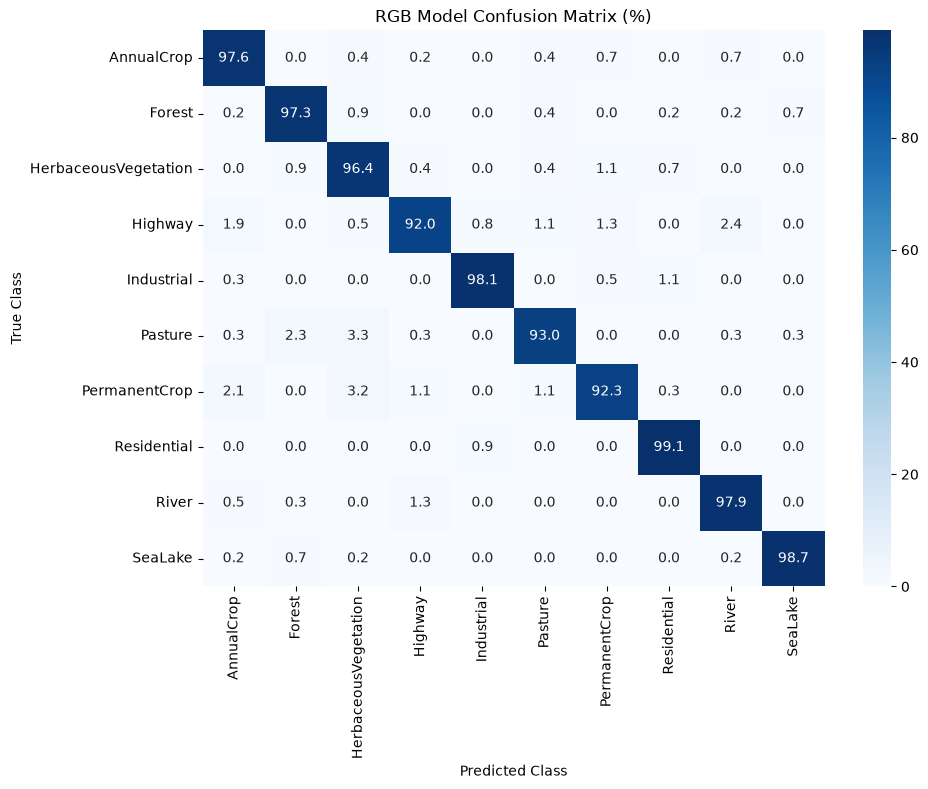

Saved: ../outputs/figures\rgb_confusion_matrix.png


In [75]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    rgb_predictions["true_label"],
    rgb_predictions["predicted_label"]
)

cm_percent = cm.astype(float)
cm_percent = cm_percent / cm_percent.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(10,8))

sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("RGB Model Confusion Matrix (%)")

plt.tight_layout()

save_path = os.path.join(
    FIGURE_DIR,
    "rgb_confusion_matrix.png"
)

plt.savefig(
    save_path,
    dpi=300
)

plt.show()

print("Saved:", save_path)

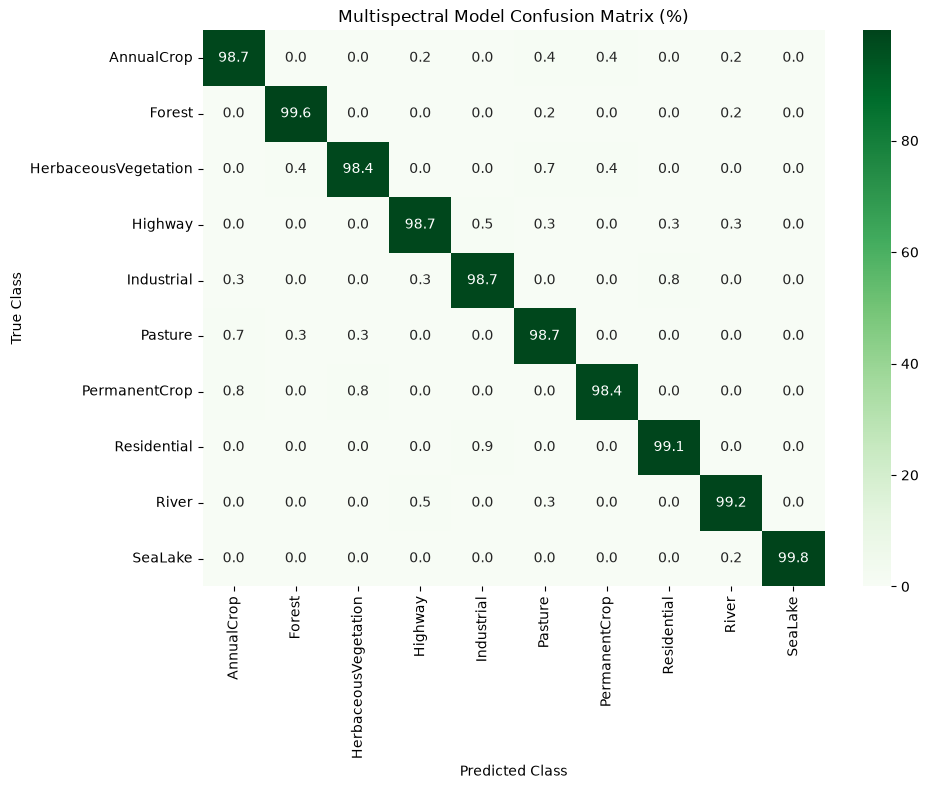

Saved: ../outputs/figures\ms_confusion_matrix.png


In [76]:
cm = confusion_matrix(
    ms_predictions["true_label"],
    ms_predictions["predicted_label"]
)

cm_percent = cm.astype(float)
cm_percent = cm_percent / cm_percent.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(10,8))

sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".1f",
    cmap="Greens",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Multispectral Model Confusion Matrix (%)")

plt.tight_layout()

save_path = os.path.join(
    FIGURE_DIR,
    "ms_confusion_matrix.png"
)

plt.savefig(
    save_path,
    dpi=300
)

plt.show()

print("Saved:", save_path)

In [77]:
cm_rgb = confusion_matrix(
    rgb_predictions["true_label"],
    rgb_predictions["predicted_label"]
)

np.fill_diagonal(cm_rgb, 0)

rgb_pairs = []

for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        if cm_rgb[i, j] > 0:
            rgb_pairs.append(
                (CLASS_NAMES[i], CLASS_NAMES[j], cm_rgb[i, j])
            )

rgb_pairs = sorted(rgb_pairs, key=lambda x: x[2], reverse=True)

rgb_confused_df = pd.DataFrame(
    rgb_pairs[:5],
    columns=["True Class", "Predicted Class", "Count"]
)

print("Top 5 RGB Confusions")
display(rgb_confused_df)

Top 5 RGB Confusions


,True Class,Predicted Class,Count
0,PermanentCrop,HerbaceousVegetation,12
1,Pasture,HerbaceousVegetation,10
2,Highway,River,9
3,PermanentCrop,AnnualCrop,8
4,Highway,AnnualCrop,7


In [78]:
cm_ms = confusion_matrix(
    ms_predictions["true_label"],
    ms_predictions["predicted_label"]
)

np.fill_diagonal(cm_ms, 0)

ms_pairs = []

for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        if cm_ms[i, j] > 0:
            ms_pairs.append(
                (CLASS_NAMES[i], CLASS_NAMES[j], cm_ms[i, j])
            )

ms_pairs = sorted(ms_pairs, key=lambda x: x[2], reverse=True)

ms_confused_df = pd.DataFrame(
    ms_pairs[:5],
    columns=["True Class", "Predicted Class", "Count"]
)

print("Top 5 MS Confusions")
display(ms_confused_df)

Top 5 MS Confusions


,True Class,Predicted Class,Count
0,Residential,Industrial,4
1,HerbaceousVegetation,Pasture,3
2,Industrial,Residential,3
3,PermanentCrop,AnnualCrop,3
4,PermanentCrop,HerbaceousVegetation,3


## Error Analysis

The confusion matrices reveal the classes that are most frequently misclassified by the RGB and multispectral models. These errors generally occur between land-cover categories with similar visual textures or spectral characteristics.

### RGB Model

The top misclassified class pairs are:

- **PermanentCrop → HerbaceousVegetation (12 samples)**
  - Both classes contain dense vegetation and similar green textures in RGB imagery, making them difficult to distinguish using only color information.

- **Pasture → HerbaceousVegetation (10 samples)**
  - Grasslands and herbaceous vegetation share comparable texture and appearance, resulting in overlapping RGB features.

- **Highway → River (9 samples)**
  - Linear structures such as highways and rivers may appear visually similar in aerial imagery, especially when surrounded by vegetation.

- **PermanentCrop → AnnualCrop (8 samples)**
  - Agricultural fields often exhibit similar planting patterns and seasonal growth, causing confusion between crop categories.

- **Highway → AnnualCrop (7 samples)**
  - Highways passing through agricultural regions may include surrounding vegetation that influences the model's prediction.

Overall, the RGB model relies primarily on color and texture information, which makes separating visually similar land-cover classes more challenging.

---

### Multispectral Model

The multispectral model shows significantly fewer misclassifications than the RGB model, demonstrating the advantage of incorporating additional Sentinel-2 spectral bands.

The top confused class pairs are:

- **Residential → Industrial (4 samples)**
  - Both classes contain buildings, roads, and other man-made structures with similar spectral characteristics.

- **HerbaceousVegetation → Pasture (3 samples)**
  - These vegetation classes have similar spectral responses, particularly during comparable growth stages.

- **Industrial → Residential (3 samples)**
  - Urban regions often contain overlapping infrastructure and construction materials, leading to occasional confusion.

- **PermanentCrop → AnnualCrop (3 samples)**
  - Similar agricultural practices and vegetation patterns can make these crop types difficult to distinguish.

- **PermanentCrop → HerbaceousVegetation (3 samples)**
  - Dense vegetation within permanent crop areas may produce spectral signatures similar to herbaceous vegetation.

Compared to the RGB model, the multispectral model exhibits substantially fewer classification errors. The additional Near Infrared (NIR), Red Edge, and Shortwave Infrared (SWIR) bands provide richer spectral information, allowing the model to better discriminate between vegetation, urban areas, and water bodies.

---

### Overall Observation

The explainability analysis demonstrates that both models primarily confuse classes with similar visual or spectral properties. However, the multispectral model achieves noticeably better class separation than the RGB model by leveraging the additional spectral information available in Sentinel-2 imagery. This improvement is reflected in the significantly lower confusion counts across all major class pairs, indicating that spectral features contribute to more robust and reliable land-cover classification.